# Attack Efficiency Analysis (NeuralHash)

This notebook loads the long-format CSV logs and produces:
- Distance vs Steps (median + IQR)
- Distance vs Time (median + IQR)
- Success Rate vs Steps/Time
- Time-to-success summary table


In [3]:
import os, sys

# IF currently inside: <repo>/fdeph_eval/analysis
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repo root:", REPO_ROOT)

Repo root: /home/exouser/ar-sec-eval


In [4]:
import os
import pandas as pd

from fdeph_eval.analysis.plotting import (
    load_attack_csv,
    summarize_run,
    plot_distance_vs_steps,
    plot_distance_vs_time,
    plot_success_rate_vs_steps,
    plot_success_rate_vs_time,
    export_time_to_success_table,
)

LOG_PATH = os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500.csv")
FIG_DIR = os.path.join(REPO_ROOT, "fdeph_eval", "analysis", "figures")
TABLE_DIR = os.path.join(REPO_ROOT, "fdeph_eval", "analysis", "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("LOG_PATH:", LOG_PATH)
print("FIG_DIR:", FIG_DIR)
print("TABLE_DIR:", TABLE_DIR)

LOG_PATH: /home/exouser/ar-sec-eval/logs/attack_steps_nhash_evasion_mt500.csv
FIG_DIR: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures
TABLE_DIR: /home/exouser/ar-sec-eval/fdeph_eval/analysis/tables


In [5]:
df = load_attack_csv(LOG_PATH)
df.head()

,image_id,hash_method,attack_type,step,elapsed_ms,dist_raw,dist_norm,l2,linf,ssim,success,source_path
1,ILSVRC2012_val_00003351__a4591751d1,nhash,evasion,1,0.001,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00003351__a...
2,ILSVRC2012_val_00003620__a6e4864228,nhash,evasion,1,0.001,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00003620__a...
3,ILSVRC2012_val_00014381__cdfef1d2c9,nhash,evasion,1,0.000,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00014381__c...
4,ILSVRC2012_val_00009111__afa522e7eb,nhash,evasion,1,0.000,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00009111__a...
5,ILSVRC2012_val_00003351__a4591751d1,nhash,evasion,2,276.762,0.0,0.0,0.0,0.0,0.0,0,./inputs/inputs_500/ILSVRC2012_val_00003351__a...


In [6]:
from fdeph_eval.analysis.plotting import time_to_success_stats, plot_time_to_success_hist

In [7]:
summary = summarize_run(df)
summary

RunSummary(n_images=500, n_succeeded=500, success_rate=1.0, median_steps_to_success=37.0, median_time_ms_to_success=5900.4805)

## Distance vs Steps

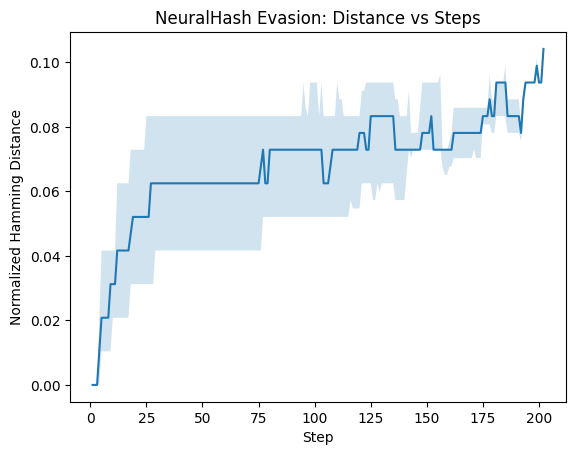

In [8]:
plot_distance_vs_steps(
    df,
    out_path=f"{FIG_DIR}/nhash_distance_vs_steps.png",
    title="NeuralHash Evasion: Distance vs Steps"
)


## Distance vs Time

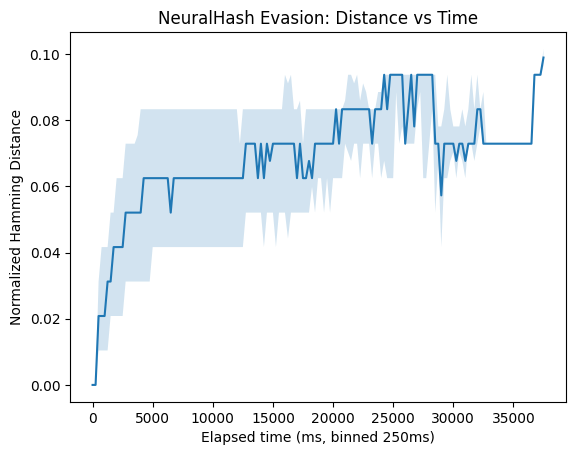

In [9]:
plot_distance_vs_time(
    df,
    bin_ms=250,
    out_path=f"{FIG_DIR}/nhash_distance_vs_time.png",
    title="NeuralHash Evasion: Distance vs Time"
)


## Success Rate vs Steps

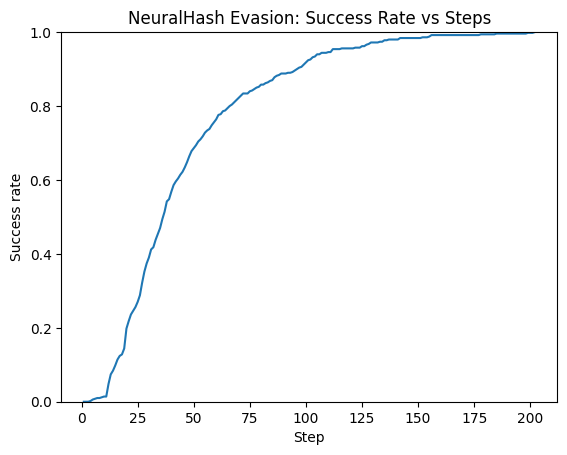

In [10]:
plot_success_rate_vs_steps(
    df,
    out_path=f"{FIG_DIR}/nhash_success_rate_vs_steps.png",
    title="NeuralHash Evasion: Success Rate vs Steps"
)


## Success Rate vs Time

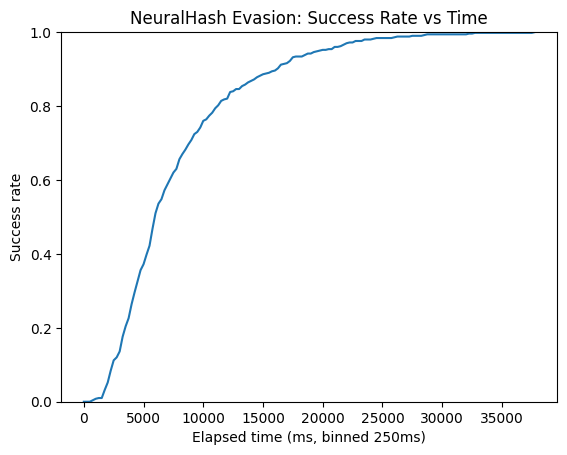

In [11]:
plot_success_rate_vs_time(
    df,
    bin_ms=250,
    out_path=f"{FIG_DIR}/nhash_success_rate_vs_time.png",
    title="NeuralHash Evasion: Success Rate vs Time"
)


## Time-to-success table

In [12]:
events = export_time_to_success_table(df, f"{TABLE_DIR}/nhash_time_to_success.csv")
events.head()

,image_id,success_step,success_elapsed_ms
0,ILSVRC2012_val_00003351__a4591751d1,37,6579.729
1,ILSVRC2012_val_00003620__a6e4864228,42,9669.798
2,ILSVRC2012_val_00009111__afa522e7eb,48,11051.095
3,ILSVRC2012_val_00014381__cdfef1d2c9,110,23483.386
4,ILSVRC2012_val_00022792__914a966190,28,3740.803


## Time-to-success Histogram

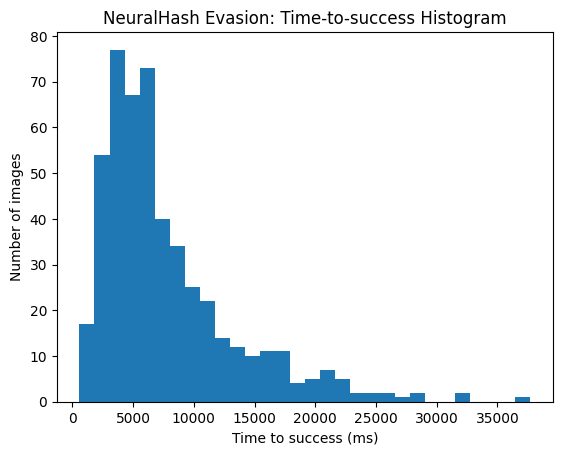

In [13]:
plot_time_to_success_hist(
    df,
    out_path=f"{FIG_DIR}/nhash_time_to_success_hist.png",
    title="NeuralHash Evasion: Time-to-success Histogram"
)

## Median + P95 table

In [14]:
stats = time_to_success_stats(df)
stats

,n_images,n_succeeded,success_rate,median_steps,p95_steps,median_time_ms,p95_time_ms
0,500,500,1.0,37.0,112.0,5900.4805,19544.64995


In [15]:
stats.to_csv(f"{TABLE_DIR}/nhash_summary_stats.csv", index=False)

## Threshold sweep analysis (compare T=0.08/0.10/0.12)

In [16]:
import pandas as pd
from fdeph_eval.analysis.plotting import load_attack_csv, time_to_success_stats

paths = {
    "T0.08": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.08.csv"),
    "T0.10": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.10.csv"),
    "T0.12": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.12.csv"),
}

rows = []
for label, p in paths.items():
    d = load_attack_csv(p)
    r = time_to_success_stats(d)
    r.insert(0, "threshold", label)
    rows.append(r)

sweep = pd.concat(rows, ignore_index=True)
sweep

,threshold,n_images,n_succeeded,success_rate,median_steps,p95_steps,median_time_ms,p95_time_ms
0,T0.08,500,500,1.0,28.0,99.0,4644.9965,16540.07220
1,T0.10,500,500,1.0,37.0,112.0,5877.9705,19032.44595
2,T0.12,500,500,1.0,44.0,130.0,7053.3145,21183.58530


In [12]:
sweep.to_csv(f"{TABLE_DIR}/nhash_threshold_sweep.csv", index=False)

## NeuralHash Threshold Sweep ? Steps + Time Bar Chart

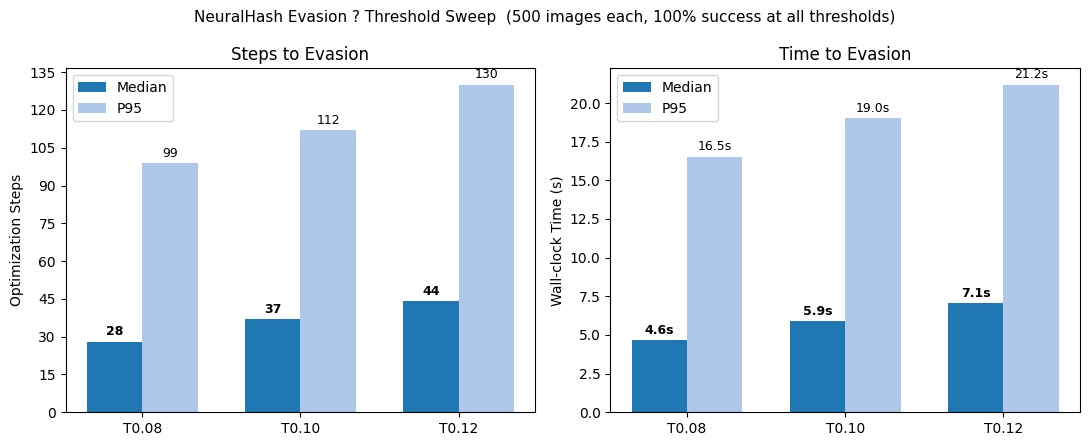

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/nhash_threshold_sweep_bars.png


In [17]:
# Produces: nhash_threshold_sweep_bars.png

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# `sweep` should already be in scope from the cells above.
# If running this cell standalone, uncomment the block below:
# ?????????????????????????????????????????????????????????????
# from fdeph_eval.analysis.plotting import load_attack_csv, time_to_success_stats
# import pandas as pd
# paths = {
#     "T0.08": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.08.csv"),
#     "T0.10": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.10.csv"),
#     "T0.12": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.12.csv"),
# }
# rows = []
# for label, p in paths.items():
#     d = load_attack_csv(p)
#     r = time_to_success_stats(d)
#     r.insert(0, "threshold", label)
#     rows.append(r)
# sweep = pd.concat(rows, ignore_index=True)
# ?????????????????????????????????????????????????????????????

THRESHOLDS   = ["T0.08", "T0.10", "T0.12"]
idx          = sweep.set_index("threshold")
med_steps    = [float(idx.loc[t, "median_steps"])    for t in THRESHOLDS]
p95_steps    = [float(idx.loc[t, "p95_steps"])       for t in THRESHOLDS]
med_time_s   = [float(idx.loc[t, "median_time_ms"]) / 1000 for t in THRESHOLDS]
p95_time_s   = [float(idx.loc[t, "p95_time_ms"])    / 1000 for t in THRESHOLDS]

x = np.arange(len(THRESHOLDS))
w = 0.35
C_MED = "#1f77b4"
C_P95 = "#aec7e8"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ?? Left panel: steps ??????????????????????????????????????????????????????
ax = axes[0]
ax.bar(x - w/2, med_steps, w, label="Median", color=C_MED)
ax.bar(x + w/2, p95_steps, w, label="P95",    color=C_P95)
for xi, (m, p) in enumerate(zip(med_steps, p95_steps)):
    ax.text(xi - w/2, m + max(p95_steps) * 0.01, f"{int(m)}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(xi + w/2, p + max(p95_steps) * 0.01, f"{int(p)}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(THRESHOLDS)
ax.set_ylabel("Optimization Steps")
ax.set_title("Steps to Evasion")
ax.legend()
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ?? Right panel: wall-clock time ???????????????????????????????????????????
ax = axes[1]
ax.bar(x - w/2, med_time_s, w, label="Median", color=C_MED)
ax.bar(x + w/2, p95_time_s, w, label="P95",    color=C_P95)
for xi, (m, p) in enumerate(zip(med_time_s, p95_time_s)):
    ax.text(xi - w/2, m + max(p95_time_s) * 0.01, f"{m:.1f}s",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(xi + w/2, p + max(p95_time_s) * 0.01, f"{p:.1f}s",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(THRESHOLDS)
ax.set_ylabel("Wall-clock Time (s)")
ax.set_title("Time to Evasion")
ax.legend()

plt.suptitle(
    "NeuralHash Evasion ? Threshold Sweep  (500 images each, 100% success at all thresholds)",
    fontsize=11
)
plt.tight_layout()

out = os.path.join(FIG_DIR, "nhash_threshold_sweep_bars.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out)

## NeuralHash Threshold Sweep ? SSIM Distribution at Success


In [ ]:
# Produces: nhash_ssim_distributions.png

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NHASH_PER_THRESHOLD = {
    "T=0.08": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.08.csv"),
    "T=0.10": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.10.csv"),
    "T=0.12": os.path.join(REPO_ROOT, "logs", "attack_steps_nhash_evasion_mt500_T0.12.csv"),
}

def _load_ssim_at_success(path):
    """
    Return an array of SSIM values at the success step for each image.

    Works with both:
    - long-format CSVs (one row per step, `step` column present): 
      filters to success==1 rows, deduplicates by taking first per image_id.
    - aggregated CSVs (one row per image, `steps` column):
      direct filter to success==1.
    """
    df = pd.read_csv(path)
    # Drop the __HYPERPARAMS__ sentinel row if present (nhash long-format logs)
    df = df[df["image_id"] != "__HYPERPARAMS__"].copy()
    df_s = df[df["success"] == 1].copy()
    if df_s.empty:
        raise ValueError(f"No success rows found in {path}")
    # Deduplicate: in long-format there may be multiple success rows per image
    step_col = "step" if "step" in df_s.columns else "steps"
    df_s = (df_s
            .sort_values(step_col)
            .groupby("image_id", as_index=False)
            .first())
    return df_s["ssim"].values

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ssim_summary = []

for ax, (label, path) in zip(axes, NHASH_PER_THRESHOLD.items()):
    ssims = _load_ssim_at_success(path)
    med   = float(np.median(ssims))

    ax.hist(ssims, bins=40, color="#1f77b4", edgecolor="white", linewidth=0.3)
    ax.axvline(med,  color="red",    lw=1.8, linestyle="--",
               label=f"Median = {med:.4f}")
    ax.axvline(0.99, color="orange", lw=1.2, linestyle=":",
               label="SSIM = 0.99")
    ax.axvline(0.95, color="gray",   lw=1.0, linestyle=":",
               label="SSIM = 0.95", alpha=0.7)
    ax.set_title(f"NeuralHash {label}")
    ax.set_xlabel("SSIM at success")
    ax.set_ylabel("Image count")
    ax.legend(fontsize=8)

    ssim_summary.append({
        "threshold":       label,
        "n":               len(ssims),
        "median_ssim":     round(med, 4),
        "pct_above_0.99":  round(100 * float((ssims >= 0.99).mean()), 1),
        "pct_below_0.95":  round(100 * float((ssims <  0.95).mean()), 1),
        "min_ssim":        round(float(ssims.min()), 4),
    })

plt.suptitle(
    "NeuralHash Evasion ? SSIM Distribution at Success\n"
    "Zero images fall below SSIM = 0.95 at any threshold; "
    "perturbations are virtually imperceptible.",
    fontsize=10
)
plt.tight_layout()

out = os.path.join(FIG_DIR, "nhash_ssim_distributions.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out)

ssim_df = pd.DataFrame(ssim_summary)
print("\nSSIM Summary:")
print(ssim_df.to_string(index=False))